In [ ]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d

import os
import sklearn.gaussian_process as gp
from scipy import stats


sys.path.append('../..')
sys.path.append('../GP_regr')
import plot_settings
import importlib
#import multi_exp_log
import SR_lib

import GP



from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)
    importlib.reload(GP)

import_reload()
GP_FIT = GP.GP_process()

# Importing data

In [ ]:
RUN_ID = 'test1'
SAVE  = True
SELECTION = 'best'
DT = 1
Q0 = 17921.57581 
ITS = int(2e4)

# check if run_id exists, if not create it
if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')

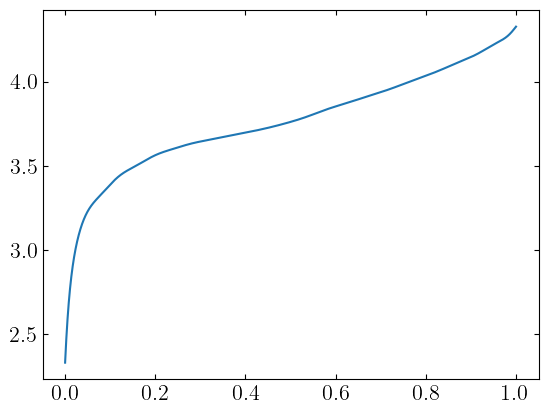

In [ ]:
soc = np.linspace(0,1.0,int(1e4))
Ue = GP.soc_to_Ue(soc,GP_FIT) 
#t = np.linspace(0,3600,int(1e4))
plt.plot(soc, Ue)

In [20]:
X_train = soc.reshape(-1,1)
Y_train = Ue.reshape(-1,1)

# $U_{eq} = f_U(\mathrm{SOC})$

Variable names for element Ue: ['soc']
Running symbolic regression for element Ue with run_id Ueq_test1...
Settings: iterations=20, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.09615141
Equation: 3.7619562

Model 1: Complexity=3, Loss=0.010166953
Equation: soc + 3.2617009

Model 2: Complexity=4, Loss=0.009426597
Equation: sqrt(soc) + 3.0953794

Model 3: Complexity=6, Loss=0.0050658197
Equation: sqrt(soc * 1.6255846) + 2.9107533

Model 4: Complexity=7, Loss=0.0040561026
Equation: sqrt(sqrt(soc * 11.588129)) + 2.2856045

Model 5: Complexity=8, Loss=0.003914141
Equation: exp(sqrt(sqrt(soc) * 0.26538774) + 0.908815)

Model 6: Complexity=10, Loss=0.002427958
Equation: sqrt(sqrt(tan(soc) * 6.821256)) + 2.4157844

Model 7: Complexity=12, Loss=0.002285551
Equation: exp(sqrt(sqrt((cube(soc) * 0.46969724) + sqrt(soc)))) + 1.2408417

Model 8: Complexity=13, Loss=0.0016489533
Equation: 2.2536123 + sqrt(sqrt(soc - square(soc - cube(soc))) * 3.9160626)

Model 9: Complexity=14, Loss=0.0014679044
Equation: sqrt(sqrt(soc - ((soc * soc) - cube(soc))) * 3.9160626) + 2.2536123

Model 10: Complexity=16, Loss=0.00065835076
Equation: sqrt(sqrt((soc - (

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 3.0626554*(-3.0306978*soc**2/(4*soc**2 + 1.2529757) + soc)**(1/4) + 1.8053592
Loss: 0.00033765074
Best model complexity: 20


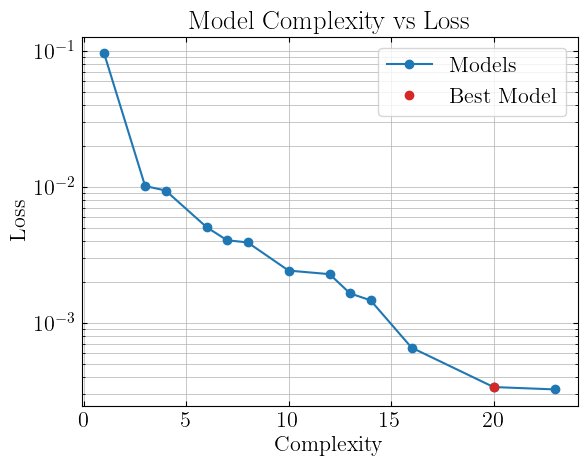

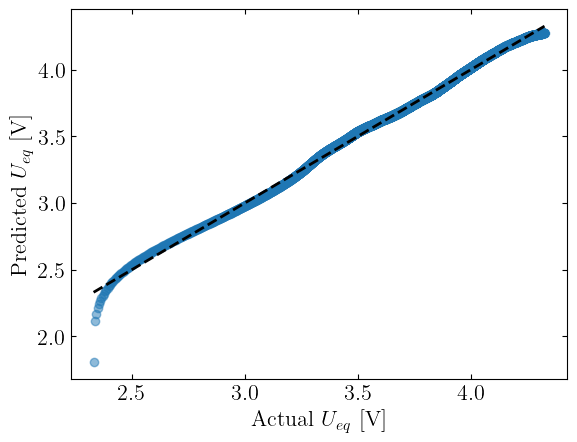

In [21]:
import_reload()
model_Ue = SR_lib.run_symbolic_regression(X_train, Y_train, model = None,run_id = f'Ueq_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'Ue')
df_model_Ue = model_Ue.equations_
SR_lib.print_models(df_model_Ue)
SR_lib.print_best_model(model_Ue)
SR_lib.pareto_plot(model_Ue)
SR_lib.parity_plot_Ue(model_Ue, Y_train, X_train, colors=colors, data_set='train')

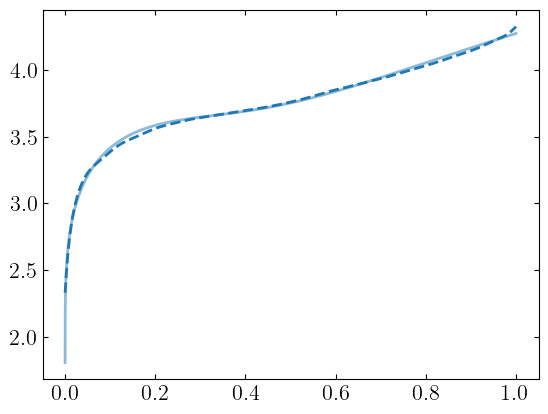

In [22]:
plt.plot(soc, model_Ue.predict(X_train), color=colors[0], alpha = 0.5, label = 'SR fit', lw = 2)
plt.plot(soc, Ue, color = colors[0],ls = '--', lw = 2, label = 'GP fit')

In [23]:
if SAVE:
    SR_lib.save_expressions(df_model_Ue,  f'Ue_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_Ue.get_best(), f'Ue_best_{RUN_ID}', run_id = RUN_ID)
    
    #save_expressions(df_model_R1, f'R1_{RUN_ID}')
    #save_expressions(df_model_C1, f'C1_{RUN_ID}')